# FER Demographic Bias Audit

This notebook audits a pretrained facial expression recognition (FER) model for demographic bias, using the FairFace dataset for age, gender and race labels.

The setup follows the standard approach in current FER-bias literature: rather than training an expression classifier from scratch, we take an existing pretrained FER model, run it on FairFace to generate expression pseudo-labels, and check whether those labels - and a downstream classifier trained on them - treat demographic subgroups differently.

**Research question:** does a pretrained facial expression model label demographic subgroups differently, and does a simple classifier trained on its output inherit or amplify that difference?

The notebook answers this two ways. Step 2b tests the FER model's own output directly, before any downstream model gets involved. Steps 3 onward build a linear baseline and an MLP on top of those labels and repeat the audit on the classifier's accuracy - useful as a second angle, but one step further removed from the original question, for reasons the write-up in step 2b and step 9 both get into.

## Step 0 - Environment setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.stats import chi2_contingency
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

DATA_DIR = '../data/'


def chi2_and_cramers_v(a, b):
    """Chi-square test of independence between two categorical columns, plus
    Cramer's V as an effect size (0 = no association, 1 = perfect association).
    Used for both the direct label audit in step 2b and the accuracy audit in
    step 9, so it only needs writing once."""
    contingency = pd.crosstab(a, b)
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.values.sum()
    r, k = contingency.shape
    v = (chi2 / (n * (min(r, k) - 1))) ** 0.5
    return chi2, p, v

I0000 00:00:1787570418.769340    3682 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787570458.786273    3682 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Step 1 - Data acquisition: FairFace

FairFace supplies the demographic labels (age, gender, race). It doesn't come with expression labels, which is what step 1b is for.

This notebook works from the full FairFace validation split, close to 11k images (see `data/prepare_dataset.py`). Running the ViT model over all of them takes fifteen to twenty minutes on CPU, so that step gets cached to disk after the first run instead of repeating on every restart.

In [2]:
df = pd.read_csv(DATA_DIR + 'fairface_labels.csv')
print(df.shape)
df.head()

(10954, 4)


,image_path,age,gender,race
0,images/val-1.jpg,3-9,Male,East Asian
1,images/val-2.jpg,50-59,Female,East Asian
2,images/val-3.jpg,30-39,Male,White
3,images/val-4.jpg,20-29,Female,Latino_Hispanic
4,images/val-5.jpg,20-29,Male,Southeast Asian


## Step 1b - Generate pseudo-labels with a pretrained FER model

Model: `trpakov/vit-face-expression`, a ViT fine-tuned on 7 expression classes (angry, disgust, fear, happy, sad, surprise, neutral).

This attaches a full expression column to FairFace's demographics without training an FER model from scratch. The tradeoff: what gets audited from here on is the ViT model's own labeling behaviour, not human-annotated ground truth. Anything biased in that model's training data is now baked into the "ground truth" this notebook treats as correct - a distinction that matters for every result below and gets revisited in the discussion.

In [3]:
import os

pred_path = DATA_DIR + 'fer_predictions.csv'

if os.path.exists(pred_path):
    preds = pd.read_csv(pred_path)
    df = df.merge(preds, on='image_path')
else:
    from transformers import pipeline

    fer_pipe = pipeline('image-classification', model='trpakov/vit-face-expression')

    def predict_emotion(rel_path):
        result = fer_pipe(DATA_DIR + rel_path, top_k=7)
        top = result[0]
        row = {'image_path': rel_path, 'emotion_pred': top['label'], 'emotion_pred_conf': top['score']}
        for r in result:
            row[f"prob_{r['label']}"] = r['score']
        return row

    records = [predict_emotion(p) for p in df['image_path']]
    preds = pd.DataFrame.from_records(records)
    preds.to_csv(pred_path, index=False)
    df = df.merge(preds, on='image_path')

df[['image_path', 'gender', 'race', 'emotion_pred', 'emotion_pred_conf']].head()

,image_path,gender,race,emotion_pred,emotion_pred_conf
0,images/val-1.jpg,Male,East Asian,neutral,0.991176
1,images/val-2.jpg,Female,East Asian,sad,0.508341
2,images/val-3.jpg,Male,White,sad,0.485897
3,images/val-4.jpg,Female,Latino_Hispanic,happy,0.879323
4,images/val-5.jpg,Male,Southeast Asian,happy,0.924316


In [4]:
df['emotion_pred'].value_counts()

emotion_pred
happy       4258
neutral     3186
sad         2016
angry        862
fear         502
surprise      97
disgust       33
Name: count, dtype: int64

Seven classes all show up, so the model isn't just defaulting to one label - a basic check that the pseudo-labels carry signal rather than being a constant. `happy` and `neutral` dominate by a wide margin, `disgust` and `surprise` barely register. FairFace is made of ordinary ID-style photos rather than acted expressions, so a skew toward calm, neutral-to-positive faces isn't surprising. It does mean `disgust` and `surprise` are too thin to say much about individually, and it sets up something to watch for later: if `happy` is disproportionately easy for the eventual classifier to get right, any group that happens to get labeled `happy` more often will look "more accurate" for reasons that have nothing to do with how well their faces are read.

## Step 2 - Exploratory data analysis

Group sizes get checked before anything else gets built, since a gap measured on 15 images means something different from a gap measured on 300. Race goes first - it's FairFace's headline demographic axis.

In [5]:
df['race'].value_counts()

race
White              2085
Latino_Hispanic    1623
Black              1556
East Asian         1550
Indian             1516
Southeast Asian    1415
Middle Eastern     1209
Name: count, dtype: int64

In [6]:
df['gender'].value_counts()

gender
Male      5792
Female    5162
Name: count, dtype: int64

In [7]:
df['age'].value_counts().sort_index()

age
0-2              199
10-19           1181
20-29           3300
3-9             1356
30-39           2330
40-49           1353
50-59            796
60-69            321
more than 70     118
Name: count, dtype: int64

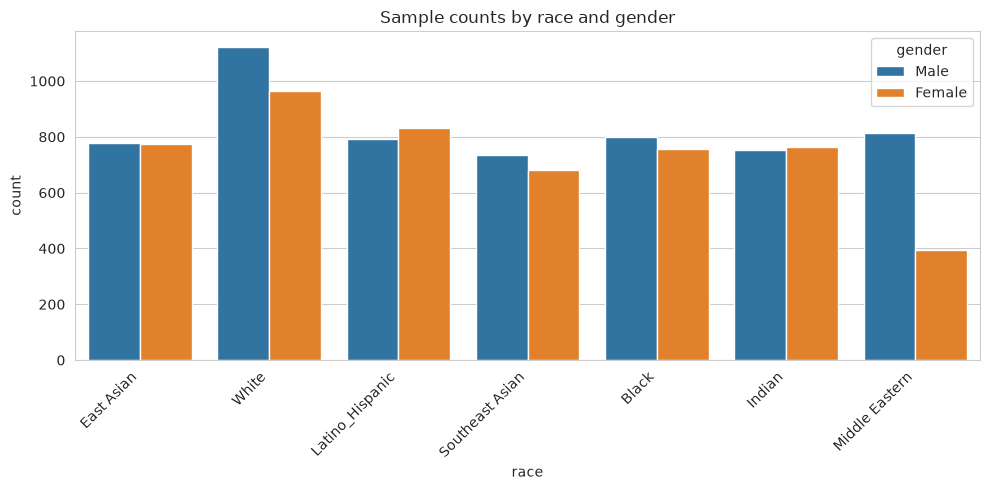

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='race', hue='gender')
plt.xticks(rotation=45, ha='right')
plt.title('Sample counts by race and gender')
plt.tight_layout()
plt.show()

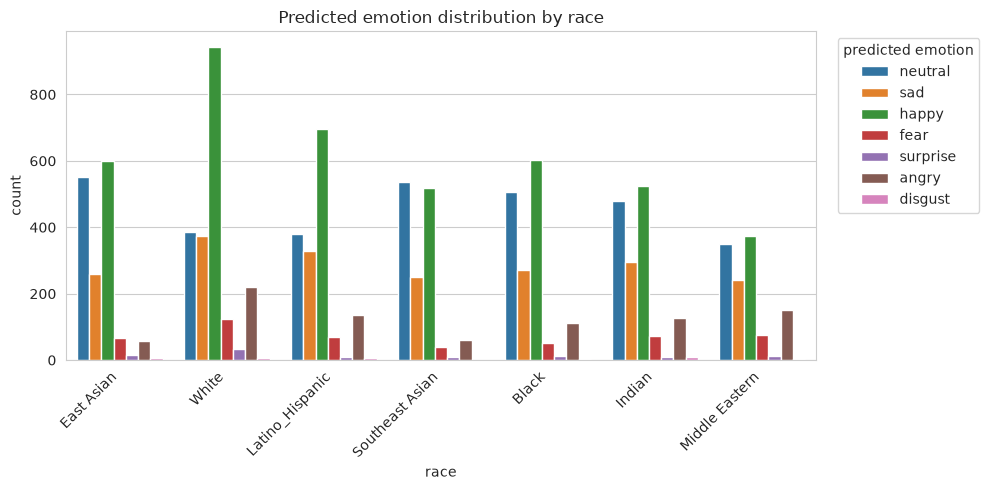

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='race', hue='emotion_pred')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='predicted emotion')
plt.title('Predicted emotion distribution by race')
plt.tight_layout()
plt.show()

In [10]:
min_group_size = df.groupby('race').size().min()
print('smallest race group:', min_group_size)
small_groups = df.groupby(['race', 'gender']).size()
print(small_groups[small_groups < 30])

smallest race group: 1209
Series([], dtype: int64)


FairFace was built to be balanced across race, and it shows - every race x gender cell in the full set clears 30 images by a wide margin. That check gets repeated later on the 20% test split specifically, since a split can easily thin out a bin that looked fine in the full data.

The chart above is also the first hint at whether emotion labels track race: if the coloured bars kept the same rough proportions across every race column, predicted emotion and race would look independent by eye. They don't look identical group to group, which is exactly what step 2b tests properly.

## Step 2b - Direct audit: does the FER model's own output vary by group?

Steps 3 onward build a classifier and check whether *its* accuracy varies by group. That's a real result, but it's an indirect one - it depends on how well an MLP happens to learn the ViT model's labels, which folds in the MLP's own quirks on top of whatever the ViT model is doing. The original question doesn't need a downstream classifier at all: does `emotion_pred`, straight out of the FER model, depend on race, gender or age? That's answerable directly from `df`, before any split or model gets involved.

Three tests get run here (race, gender, age), so a plain 0.05 threshold overstates how much evidence is needed - Bonferroni correction divides the threshold by 3 to keep the overall false-positive rate at 5% across the family of tests. Cramer's V comes along for effect size: with a set this large, a p-value alone can't distinguish a gap worth caring about from one that's statistically real but tiny.

In [11]:
alpha = 0.05
alpha_corrected = alpha / 3  # three demographic axes tested here: race, gender, age
print(f'Bonferroni-corrected threshold for 3 tests: {alpha_corrected:.4f}')
print()

direct_results = {}
for axis in ['race', 'gender', 'age']:
    chi2, p, v = chi2_and_cramers_v(df[axis], df['emotion_pred'])
    direct_results[axis] = (chi2, p, v)
    verdict = 'significant' if p < alpha_corrected else 'not significant'
    print(f"{axis:8s}  chi2={chi2:8.2f}  p={p:.4g}  Cramer's V={v:.3f}  ({verdict} after correction)")

Bonferroni-corrected threshold for 3 tests: 0.0167

race      chi2=  399.92  p=5.782e-63  Cramer's V=0.078  (significant after correction)
gender    chi2=  545.67  p=1.21e-114  Cramer's V=0.223  (significant after correction)
age       chi2=  858.41  p=5.761e-149  Cramer's V=0.114  (significant after correction)


Cramer's V for a 2x7 or 2x9 table this size is on a rough scale where under about 0.1 counts as small, 0.1-0.3 as moderate, and above 0.3 as strong - so these numbers are the ones that decide whether a significant result is also a practically meaningful one, not just a detectable one given how much data there is. Read together with the p-values above, this is the most direct answer the notebook has to the original research question: whether the FER model's raw output already differs by group, independent of anything a downstream classifier does with it.

## Step 3 - Preprocessing

From here on the notebook builds and audits a downstream classifier, as a second, complementary angle on the same question. Images get converted to grayscale pixel arrays, scaled to 0-1, and resized to 48x48 - small enough to keep the baseline and MLP quick while leaving enough detail to separate expressions.

In [12]:
def load_image(rel_path, size=(48, 48)):
    img = load_img(DATA_DIR + rel_path, target_size=size, color_mode='grayscale')
    return img_to_array(img) / 255.0

X = np.array([load_image(p) for p in df['image_path']])
y = df['emotion_pred']

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, df, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((8763, 48, 48, 1), (2191, 48, 48, 1))

`meta_train` / `meta_test` ride along with the split so results can be sliced by race, gender and age afterwards - the split itself only needs `X` and `y`, but the demographic columns have to stay aligned to the same rows to be usable later.

In [13]:
age_test_counts = meta_test['age'].value_counts().sort_index()
print(age_test_counts)
print()
small_test_cells = meta_test.groupby(['race', 'gender']).size()
print('race x gender cells under 30 in the test split:')
print(small_test_cells[small_test_cells < 30])

age
0-2              34
10-19           236
20-29           680
3-9             282
30-39           461
40-49           265
50-59           140
60-69            69
more than 70     24
Name: count, dtype: int64

race x gender cells under 30 in the test split:
Series([], dtype: int64)


This is the check from step 2 repeated on `meta_test` specifically, since that's the data step 9's tests actually run on - a group clearing 30 images in the full set doesn't guarantee it still does after a 20% split takes a random fifth of it away. Any age bin (or race x gender cell) that shows up above should be read with real caution in everything that follows: an accuracy number computed on a couple dozen images swings a lot from one random split to the next, in a way a 5-figure sample doesn't.

## Step 4 - Baseline: linear (softmax) classifier

The "standard classifier" comparison point - a straight decision boundary, expected to underperform. It sets a floor the MLP in the next step is supposed to clear.

In [14]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

baseline = LogisticRegression(max_iter=3000)
baseline.fit(X_train_flat, y_train)
baseline_preds = baseline.predict(X_test_flat)
print('Baseline accuracy:', accuracy_score(y_test, baseline_preds))

Baseline accuracy: 0.5093564582382474


A linear decision boundary can only separate classes with a straight line, or a flat plane once there are more than two pixel dimensions to work with. Where two groups' faces overlap in a complicated, curved way in that pixel space, a straight cut through it won't separate them cleanly - which is the whole motivation for the MLP next.

## Step 5 - Non-linear model (MLP)

Hidden layers plus a non-linear activation (ReLU) let the decision boundary bend instead of staying flat. That's the capability the linear model above doesn't have.

In [15]:
n_classes = y.nunique()
class_names = sorted(y.unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}

y_train_idx = y_train.map(class_to_idx).values
y_test_idx = y_test.map(class_to_idx).values

def build_mlp(learning_rate):
    model = keras.Sequential([
        keras.layers.Input(shape=X_train.shape[1:]),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

mlp = build_mlp(learning_rate=0.01)
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,751 (1.16 MB)

 Trainable params: 303,751 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 - Training

The model guesses, measures how wrong the guess was (the loss), and nudges its weights a bit in the direction that reduces that wrongness. `learning_rate` sets the size of that nudge - too big and it overshoots and never settles, too small and it crawls. Keras runs the actual gradient computation; the point of the sweep below is to see the effect of that one number directly rather than trust it blindly.

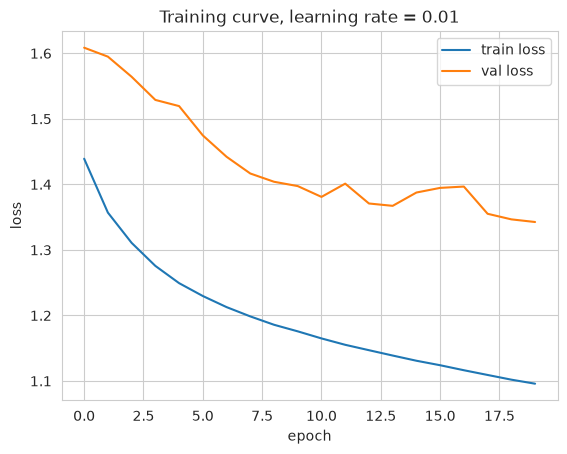

MLP test accuracy (lr=0.01): 0.48014605045318604


In [16]:
history = mlp.fit(
    X_train, y_train_idx,
    validation_split=0.1, epochs=20, batch_size=32, verbose=0
)

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Training curve, learning rate = 0.01')
plt.show()

test_loss, test_acc = mlp.evaluate(X_test, y_test_idx, verbose=0)
print('MLP test accuracy (lr=0.01):', test_acc)

lr=0.1    test accuracy=0.4906


lr=0.01   test accuracy=0.4728


lr=0.001  test accuracy=0.5276


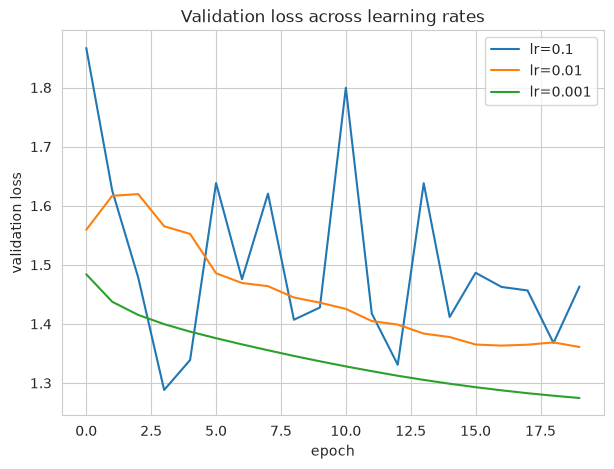

In [17]:
results = {}
for lr in [0.1, 0.01, 0.001]:
    m = build_mlp(learning_rate=lr)
    h = m.fit(X_train, y_train_idx, validation_split=0.1, epochs=20, batch_size=32, verbose=0)
    test_loss, test_acc = m.evaluate(X_test, y_test_idx, verbose=0)
    results[lr] = {'history': h.history, 'test_acc': test_acc}
    print(f'lr={lr:<6} test accuracy={test_acc:.4f}')

plt.figure(figsize=(7, 5))
for lr, r in results.items():
    plt.plot(r['history']['val_loss'], label=f'lr={lr}')
plt.xlabel('epoch')
plt.ylabel('validation loss')
plt.legend()
plt.title('Validation loss across learning rates')
plt.show()

One epoch here is over 270 batches rather than the couple dozen you'd get on a small dataset, so even a small learning rate accumulates a lot of updates per epoch. `lr=0.1` and `lr=0.01` both stay jagged from epoch to epoch, overshooting on plenty of steps, while `lr=0.001` traces a smooth curve that ends up lowest by epoch 20. The takeaway isn't "smaller is always better" - it's that the right rate depends on how many gradient steps you're actually taking, which itself depends on dataset size and batch size, not on the learning rate in isolation.

## Step 7 - Gradient checking demo

Keras's gradients are already implemented and verified, so the MLP above doesn't need this. It's a small standalone check that the concept behind gradient checking holds: a numerical gradient (nudge the input, measure the change in output) should land close to the calculus-derived analytical gradient.

In [18]:
def f(x):
    return x ** 2  # derivative is 2x

def numeric_gradient(f, x, h=1e-4):
    return (f(x + h) - f(x - h)) / (2 * h)

x = 3.0
print('Numeric gradient:', numeric_gradient(f, x))
print('Analytical gradient (2x):', 2 * x)

Numeric gradient: 6.000000000012662
Analytical gradient (2x): 6.0


## Step 8 - Subgroup evaluation of the downstream classifier

The MLP trained at `lr=0.01` gets evaluated on the held-out test set, then its accuracy gets broken down by race, gender and both together. This is the classifier-accuracy angle flagged in the introduction - complementary to step 2b, not a replacement for it, and read together with the caveat from step 3 about which test-set cells are small enough to be noisy.

In [19]:
mlp_preds = mlp.predict(X_test, verbose=0).argmax(axis=1)
meta_test = meta_test.copy()
meta_test['correct'] = (mlp_preds == y_test_idx)

subgroup_accuracy = meta_test.groupby(['race', 'gender'])['correct'].mean()
subgroup_accuracy

race             gender
Black            Female    0.525180
                 Male      0.508876
East Asian       Female    0.489933
                 Male      0.402367
Indian           Female    0.561728
                 Male      0.490566
Latino_Hispanic  Female    0.536145
                 Male      0.460123
Middle Eastern   Female    0.577465
                 Male      0.392265
Southeast Asian  Female    0.561983
                 Male      0.531915
White            Female    0.484043
                 Male      0.342723
Name: correct, dtype: float64

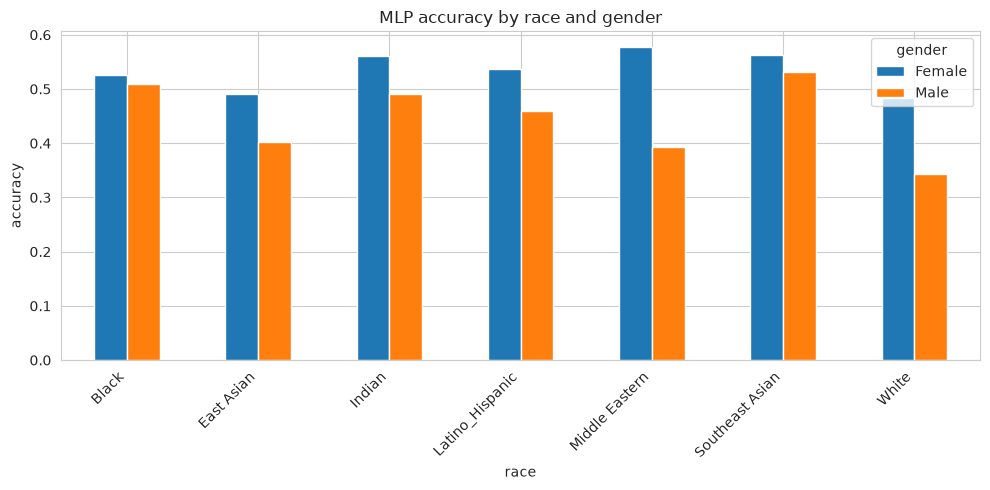

In [20]:
subgroup_accuracy.unstack().plot(kind='bar', figsize=(10, 5))
plt.ylabel('accuracy')
plt.title('MLP accuracy by race and gender')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

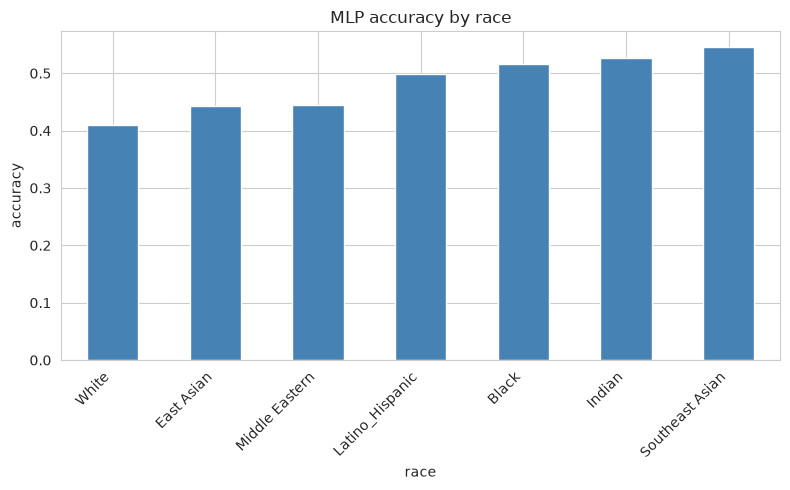

race
White              0.408978
East Asian         0.443396
Middle Eastern     0.444444
Latino_Hispanic    0.498480
Black              0.516234
Indian             0.526480
Southeast Asian    0.545802
Name: correct, dtype: float64

In [21]:
race_accuracy = meta_test.groupby('race')['correct'].mean().sort_values()
race_accuracy.plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.ylabel('accuracy')
plt.title('MLP accuracy by race')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
race_accuracy

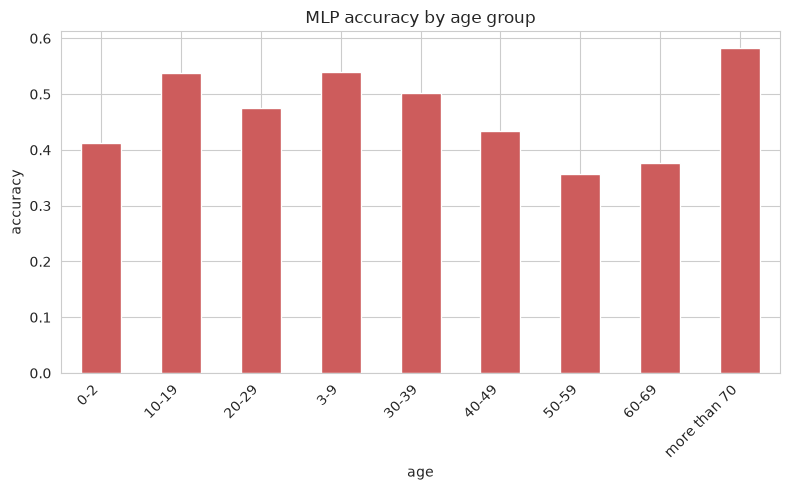

age
0-2             0.411765
10-19           0.538136
20-29           0.475000
3-9             0.539007
30-39           0.501085
40-49           0.433962
50-59           0.357143
60-69           0.376812
more than 70    0.583333
Name: correct, dtype: float64

In [22]:
age_accuracy = meta_test.groupby('age')['correct'].mean().sort_index()
age_accuracy.plot(kind='bar', figsize=(8, 5), color='indianred')
plt.ylabel('accuracy')
plt.title('MLP accuracy by age group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
age_accuracy

Female accuracy sits above male accuracy in nearly every row of the race x gender table, which is a pattern worth carrying into the significance test rather than reading off the bar chart alone. Race shows spread too, though less consistently than gender does. Step 9 checks both against chance.

## Step 9 - Statistical significance testing

Same logic as step 2b, applied to the downstream classifier instead of the raw FER labels: a chi-square test on correct/incorrect counts per group, Bonferroni-corrected for three tests, with Cramer's V alongside each p-value.

One thing to flag before reading the numbers: `emotion_pred` is heavily skewed toward `happy` and `neutral` (step 1b). If one demographic group happens to get labeled `happy` more often than another - which step 2b tests directly - the MLP will look more "accurate" for that group simply because predicting the majority class is easier, regardless of whether it reads that group's faces any better or worse. That confound is exactly why step 2b's direct test on `df` matters: it isolates whether the FER model's labels vary by group, without this classifier-accuracy effect mixed in. The numbers below are still useful, just as evidence about what a downstream classifier does with already-biased labels, not as a clean re-measurement of the same thing.

In [23]:
alpha_corrected = 0.05 / 3  # same 3-test correction as step 2b

downstream_results = {}
for axis in ['race', 'gender', 'age']:
    chi2, p, v = chi2_and_cramers_v(meta_test[axis], meta_test['correct'])
    downstream_results[axis] = (chi2, p, v)
    verdict = 'significant' if p < alpha_corrected else 'not significant'
    print(f"{axis:8s}  chi2={chi2:8.2f}  p={p:.4g}  Cramer's V={v:.3f}  ({verdict} after correction)")

race      chi2=   20.48  p=0.002274  Cramer's V=0.097  (significant after correction)
gender    chi2=   16.48  p=4.911e-05  Cramer's V=0.087  (significant after correction)
age       chi2=   23.34  p=0.002956  Cramer's V=0.103  (significant after correction)


`p < 0.05` uncorrected is the usual rule of thumb, but three tests were run here, so the corrected threshold from step 2b applies again. Whatever comes back significant at that stricter bar is evidence the MLP's accuracy moves with a demographic axis in a way three separate 5%-level tests together would not produce by chance; anything that only clears the uncorrected 0.05 is weaker than the write-up in step 11 treats it.

## Step 10 - Error analysis

An accuracy table says how often the model is wrong, not what it confuses. Pulling out actual misclassified images is what turns the number into an explanation - the same facial features (skin tone, facial hair, lighting) can tip an ambiguous expression toward the wrong label depending on the rest of the face around it, the way a word's meaning shifts with the words next to it.

In [24]:
errors = meta_test[~meta_test['correct']]
errors_by_group = errors.groupby(['race', 'gender']).size().sort_values(ascending=False)
errors_by_group.head(10)

race             gender
White            Male      140
Middle Eastern   Male      110
East Asian       Male      101
White            Female     97
Latino_Hispanic  Male       88
Black            Male       83
Indian           Male       81
Latino_Hispanic  Female     77
East Asian       Female     76
Indian           Female     71
dtype: int64

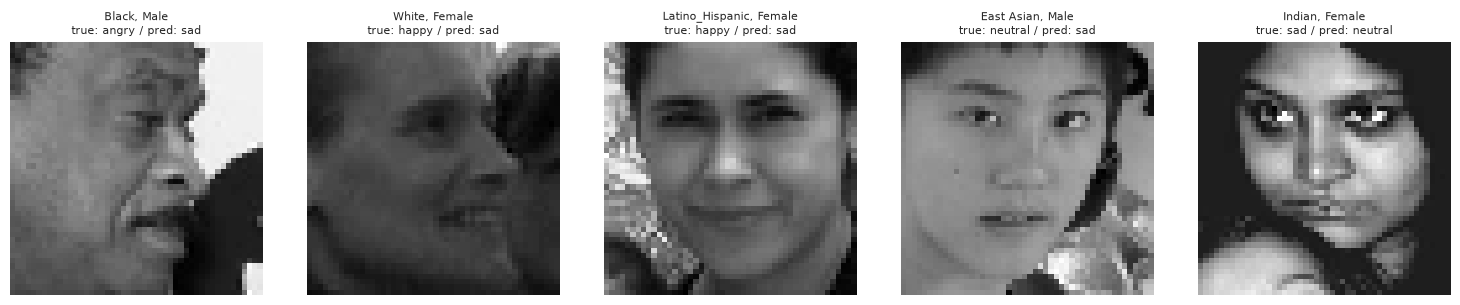

In [25]:
sample_errors = errors.sample(min(5, len(errors)), random_state=1)

fig, axes = plt.subplots(1, len(sample_errors), figsize=(3 * len(sample_errors), 3))
if len(sample_errors) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_errors.index):
    pos = meta_test.index.get_loc(idx)
    ax.imshow(X_test[pos].squeeze(), cmap='gray')
    true_label = y_test.loc[idx]
    pred_label = class_names[mlp_preds[pos]]
    ax.set_title(f"{meta_test.loc[idx, 'race']}, {meta_test.loc[idx, 'gender']}\ntrue: {true_label} / pred: {pred_label}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

Male subgroups fill most of the top rows of the error-count table, tracking the gender result from step 9. The five sampled images below are a smaller, visual check on top of that count - a look at what actually gets confused (neutral with sad, surprise with fear come up more than once) rather than who it happens to. Both readings sit alongside each other; neither one substitutes for the quantitative test.

## Step 11 - Report write-up

**Restated research question.** Does a pretrained FER model label demographic subgroups differently, and does a classifier trained on its output inherit or amplify that difference?

**Data source and limitations.** Age, gender and race come from FairFace, built specifically for balanced representation across race. Expression labels are not part of FairFace - they come from `trpakov/vit-face-expression`, so what gets audited is that model's labeling behaviour, not human-annotated ground truth. Any bias already in the ViT model's training data lands directly in what this notebook treats as ground truth: "group X gets labeled happy less often" reflects the ViT model's own output, not an independently verified fact about group X's expressions. The full FairFace validation split is used throughout. Step 3's test-set size check turns up one cell worth flagging: the oldest age bin (more than 70) drops to 24 images in the 20% test split, under the 30-sample floor used elsewhere, so the age breakdown in step 9 should be read with that specific bin discounted.

**Direct audit of the FER model's labels (step 2b).** This is the primary result, since it tests the research question without a downstream classifier standing in the way, on the full 10,954-row set. All three axes come back significant even after Bonferroni correction (threshold 0.0167 for three tests), but the effect sizes are not close to each other: gender's Cramer's V is 0.22, in the moderate range; age comes in at 0.11 and race at 0.08, both small. In plain terms, the ViT model's predicted-emotion mix depends fairly substantially on gender, and only mildly on race or age, even though all three gaps are too large to be chance at this sample size.

**Baseline vs MLP performance.** Baseline and default-MLP (`lr=0.01`) test accuracy land close together (about 51% vs 48%), with no clear edge for the non-linear model - the learning-rate sweep explains why: `lr=0.1` and the sweep's own `lr=0.01` run both underperform the baseline, and `lr=0.001` is the one setting that pulls ahead of it, at around 53%. The pattern is "the MLP can beat the linear model, once its learning rate is matched to how much data it's training on" rather than "the MLP straightforwardly wins."

**Subgroup accuracy and significance of the downstream classifier (step 9).** All three axes are significant here too, after the same correction - but where step 2b's effect sizes were spread across small to moderate, step 9's are clustered together and uniformly small: V is 0.10 for race, 0.09 for gender, 0.10 for age. That's a genuinely different shape of result from step 2b, where gender stood well apart from the other two. Given the class-imbalance confound flagged going into step 9, that flattening is at least partly expected: a downstream classifier scored on raw accuracy will pick up some of each group's `happy`/`neutral` label mix regardless of how well it reads faces, which would tend to blur out the sharper gender signal that step 2b measures directly.

**Qualitative error analysis.** The error-count table in step 10 lines up with the gender result reported in step 9; the five sampled images are a small supplementary look at what the model confuses (similar-looking expressions) rather than a second measurement of who it's wrong about.

**Discussion.** Two questions got asked here, and the answers agree on direction but disagree on shape. Does the FER model's own output vary by demographic group - yes, and unevenly: gender's effect (V = 0.22) is roughly twice the size of age's (0.11) and nearly three times race's (0.08). Does a downstream classifier's accuracy also vary by group - also yes, but with all three axes landing at a similarly small effect size (V around 0.09-0.10) rather than gender standing out the way it did in the direct test. Three explanations are worth keeping distinct, since they call for different follow-ups: inherited bias (the ViT model already treats groups differently at the label level, which step 2b measures directly and is the cleanest evidence in the notebook); a class-imbalance confound in the classifier stage (a group with an easier `happy`/`neutral`-heavy label mix scores higher regardless of face-reading quality, which is a plausible reason step 9's gender effect looks smaller than step 2b's - addressed by re-running step 9 conditioned on emotion class, or on a class-balanced subset); and downstream representation effects (a 48x48 grayscale MLP may lean on skin tone, contrast or hairstyle rather than expression, though the baseline performing about as well as the MLP argues against this being the dominant factor here). The step 2b result is the one that stands on its own without needing any of these three disentangled first, and gender is where it points most clearly.

**Limitations and next steps.** The audited "ground truth" is a model's output, not a human label - rerunning this same two-part audit (direct label test plus downstream classifier test) against a human-annotated dataset like RAF-DB or AffectNet with demographic metadata would show whether the same pattern, and the same gender-dominant shape, holds against real annotations. Re-running step 9 conditioned on emotion class, or restricted to just the `happy`/`neutral` majority classes, would separate the class-imbalance confound from a genuine face-reading gap. Pulling in FairFace's train split would help specifically with the age-70+ test-set cell flagged in step 3. A convolutional model would likely raise accuracy across the board and could shift which groups look disadvantaged in the downstream analysis, so those specific numbers describe this pipeline, not FER bias in general - step 2b's result, by contrast, is a property of the released ViT model itself and should hold regardless of what classifier gets built on top of it.